|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Metaparameters (activations, optimizers)<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge: Minibatch size in the wine dataset<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
### import libraries
%matplotlib widget 

# for DL modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

# for number-crunching
import numpy as np
import scipy.stats as stats

# for dataset management
import pandas as pd

# for timing computations
import time

# for data visualization
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [2]:
# import the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url,sep=';')
data = data[data['total sulfur dioxide']<200] # drop a few outliers

# z-score all columns except for quality
data = data.apply(stats.zscore)

data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03
mean,3.559388e-17,1.245786e-16,1.779694e-17,-9.788316e-17,-1.423755e-16,8.898469e-18,-5.339081e-17,-8.361001e-14,3.025479e-16,8.898469e-17,-5.695020e-16,4.182280e-16
std,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00
min,-2.136087e+00,-2.280762e+00,-1.391823e+00,-1.169149e+00,-1.604575e+00,-1.422837e+00,-1.262581e+00,-3.546932e+00,-3.709380e+00,-1.937318e+00,-1.899221e+00,-3.266852e+00
25%,-7.006076e-01,-7.718255e-01,-9.286769e-01,-4.525789e-01,-3.721412e-01,-8.478700e-01,-7.596977e-01,-6.111392e-01,-6.587444e-01,-6.392206e-01,-8.653154e-01,-7.866225e-01
50%,-2.412541e-01,-4.530063e-02,-5.384522e-02,-2.376079e-01,-1.809014e-01,-1.770746e-01,-2.568145e-01,-6.216372e-04,-9.673073e-03,-2.261897e-01,-2.073755e-01,4.534922e-01
75%,5.051954e-01,6.253377e-01,7.695258e-01,4.902022e-02,5.283609e-02,4.937208e-01,4.975104e-01,5.780428e-01,5.744912e-01,4.228588e-01,6.385471e-01,4.534922e-01
max,4.352281e+00,5.878672e+00,3.754246e+00,9.292776e+00,1.112349e+01,5.380944e+00,3.734821e+00,3.683719e+00,4.533826e+00,7.916418e+00,4.210221e+00,2.933721e+00


# Re-organize the data: train/test in DataLoaders

In [3]:
# convert from pandas dataframe to tensor
cols2zscore = data.keys()
cols2zscore = cols2zscore.drop('residual sugar')

dataT  = torch.tensor( data[cols2zscore].values ).float()
labels = torch.tensor( data['residual sugar'].values ).float() # labels is wrong name here, shall be targets, but leave as is for simplicity
labels = labels[:,None] # transform to matrix

In [4]:
# use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labels, test_size=.1)

# then convert them into PyTorch Datasets (note: already converted to tensors)
train_dataDataset = TensorDataset(train_data,train_labels)
test_dataDataset  = TensorDataset(test_data,test_labels)

# Create Data Loaders:
batchsize = 32
train_loader = DataLoader(train_dataDataset, batch_size=batchsize, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataDataset,batch_size=test_dataDataset.tensors[0].shape[0])

# Now for the DL part

In [8]:
# create a class for the model
class ANNwine(nn.Module):
  def __init__(self):
    super().__init__()

    self.input = nn.Linear(11,10)
    self.fc1 = nn.Linear(10,16)
    self.fc2 = nn.Linear(16,8)
    self.output = nn.Linear(8,1)

  # forward pass
  def forward(self,x):
    x = F.relu( self.input(x) )
    x = F.relu( self.fc1(x) )
    x = F.relu( self.fc2(x) )
    return self.output(x)

In [9]:
# Use dummy data sets for quick testing
wnet = ANNwine()
Xdummy = torch.randn(3,11)
ydummy = wnet(Xdummy)
print(ydummy.detach().numpy())
assert ydummy.shape==(Xdummy.shape[0],1)

[[0.14247774]
 [0.15151   ]
 [0.13314079]]


# Train the model

In [10]:
# a function that trains the model

def trainTheModel(net, train_loader, test_loader, numepochs=1000, learningRate=.001):

  # loss function and optimizer
  lossfun = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(),lr=learningRate)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss = torch.zeros(numepochs)
  trainAcc = torch.zeros(numepochs)
  testAcc = torch.zeros(numepochs)

  acc_fn = lambda yHat, y: np.min(np.corrcoef( yHat.detach().numpy().flatten(), y.detach().numpy().flatten() ))

  # loop over epochs
  for epochi in range(numepochs):

    # switch on training mode
    net.train()

    # loop over training data batches
    batchLoss = []
    batchAcc = []
    for X, y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)
      
      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and accuracy from this batch
      batchLoss.append(loss.item())
      batchAcc.append(acc_fn(yHat,y))
    # end of batch loop...

    # Aaverage losses across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainAcc[epochi] = np.mean(batchAcc)

    # test accuracy
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
    testLoss[epochi] = np.mean(lossfun(yHat,y).item())
    testAcc[epochi] = acc_fn(yHat,y)

  # function output
  return trainLoss, testLoss, trainAcc, testAcc

# Run Experiment
# Create and train a model
numepochs = 500
winenet = ANNwine()
trainLoss,testLoss,trainAcc,testAcc = trainTheModel(winenet, train_loader, test_loader, numepochs=numepochs)

In [11]:
# Compute metrics for predicted and true values:
yHatTrain = winenet(train_data).detach().numpy().flatten()
rTrain = np.min(np.corrcoef(train_labels.numpy().flatten(), yHatTrain))
print('rTrain = ', rTrain)

yHatTest = winenet(test_data).detach().numpy().flatten()
rTest = np.min(np.corrcoef(test_labels.numpy().flatten(), yHatTest))
print('rTest = ', rTest)

rTrain =  0.9565863139027202
rTest =  0.7640801427834811


# Visualize Results

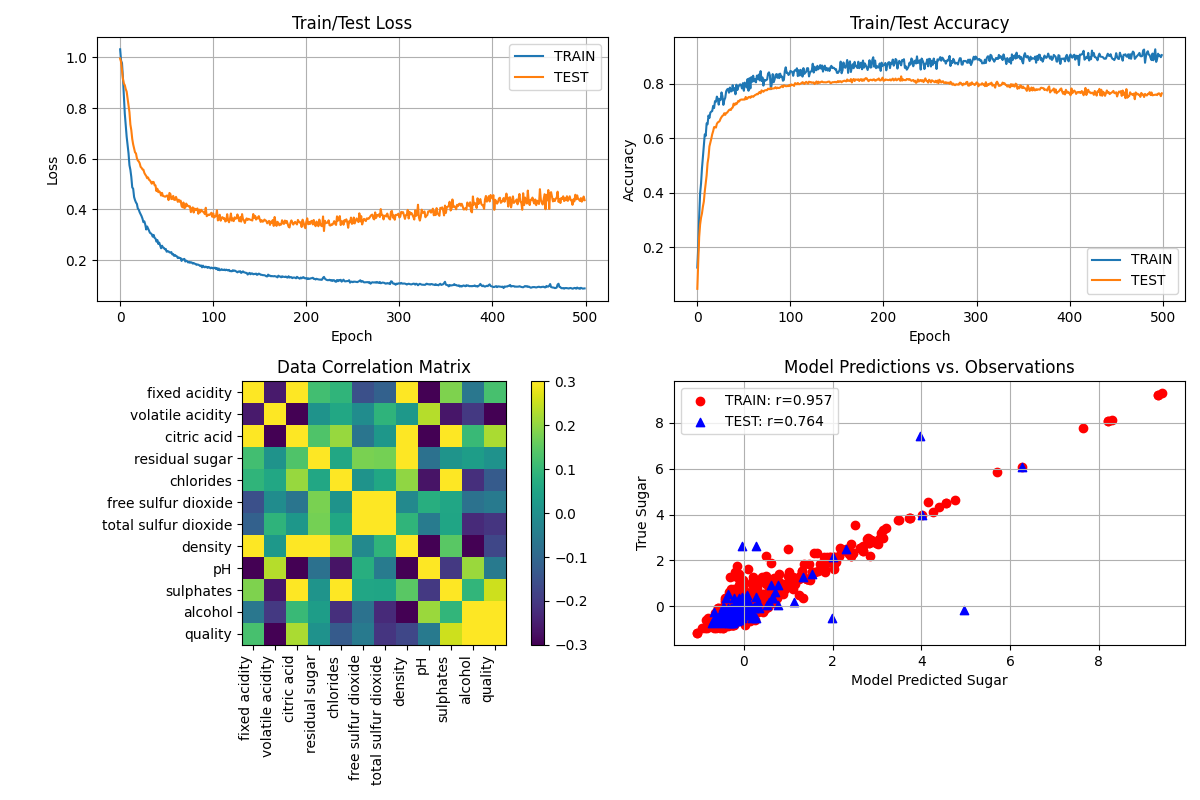

In [14]:
# Check if the variable 'fig' is defined
if 'fig' in locals(): del fig,ax
fig,ax = plt.subplots(2,2,figsize=(12,8))

ax[0,0].plot(trainLoss)
ax[0,0].plot(testLoss)
ax[0,0].set_title('Train/Test Loss')
ax[0,0].legend(['TRAIN','TEST'])
ax[0,0].set_xlabel('Epoch')
ax[0,0].set_ylabel('Loss')
ax[0,0].grid()

ax[0,1].plot(trainAcc)
ax[0,1].plot(testAcc)
ax[0,1].set_title('Train/Test Accuracy')
ax[0,1].legend(['TRAIN','TEST'])
ax[0,1].set_xlabel('Epoch')
ax[0,1].set_ylabel('Accuracy')
ax[0,1].grid()

ax[1,1].scatter(yHatTrain, train_labels.numpy(), c='r', marker='o')
ax[1,1].scatter(yHatTest, test_labels.numpy(), c='b', marker='^')
ax[1,1].set_title('Model Predictions vs. Observations')
ax[1,1].legend([f'TRAIN: r={np.min(rTrain):0.3f}', f'TEST: r={np.min(rTest):0.3f}'])
ax[1,1].set_xlabel('Model Predicted Sugar')
ax[1,1].set_ylabel('True Sugar')
ax[1,1].grid()

dataCorrelationMatrix = torch.corrcoef(torch.tensor(data.values).float().T)
im = ax[1,0].imshow(dataCorrelationMatrix,vmin=-.3,vmax=.3)
ax[1,0].set_title('Data Correlation Matrix')
ax[1,0].set_xticks(np.arange(len(data.keys())))
ax[1,0].set_yticks(np.arange(len(data.keys())))
ax[1,0].set_xticklabels(data.keys(), rotation=90, ha='right')
ax[1,0].set_yticklabels(data.keys())
plt.colorbar(im, ax=ax[1,0])

plt.tight_layout()
plt.show()

# Additional explorations

In [ ]:
# 1) There is another regularization technique called "early stopping," which simply means to stop training the model
#    earlier than the number of epochs you specified. Early stopping is used when the test accuracy starts to decrease
#    with increased training. Do you think that early stopping would be beneficial here? How many epochs would you train?
#
# 2) The training loop computes the losses, but those aren't plotted. Create an additional subplot to show the losses
#    in a similar fashion as the accuracy. Does that plot provide any additional insights into the effects of minibatch
#    size, beyond what we can already learn from the accuracy plots.
#